In [10]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os

import time

import copy

import random

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from PIL import Image

from tqdm import tqdm

# ============================================================
# PYTORCH
# ============================================================

import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import DataLoader

# ============================================================
# TORCHVISION
# ============================================================

import torchvision

from torchvision import datasets

from torchvision import transforms

from torchvision import models

# ============================================================
# SKLEARN METRICS
# ============================================================

from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    accuracy_score,

    roc_curve,

    auc
)

from sklearn.preprocessing import label_binarize

# ============================================================
# LR SCHEDULER
# ============================================================

from torch.optim.lr_scheduler import ReduceLROnPlateau

# ============================================================
# IGNORE WARNINGS
# ============================================================

warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [12]:
# ============================================================
# DEVICE CONFIGURATION
# ============================================================

device = torch.device(

    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*50)

print(f"Using Device: {device}")

print("="*50)

# ============================================================
# GPU INFORMATION
# ============================================================

if torch.cuda.is_available():

    print(

        f"GPU Name: "
        f"{torch.cuda.get_device_name(0)}"
    )

    print(

        f"CUDA Version: "
        f"{torch.version.cuda}"
    )

    print(

        f"GPU Count: "
        f"{torch.cuda.device_count()}"
    )

    total_memory = (

        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

    print(

        f"GPU Memory: "
        f"{total_memory:.2f} GB"
    )

else:

    print("CUDA GPU Not Available!")

print("="*50)

Using Device: cuda
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 12.8
GPU Count: 1
GPU Memory: 7.96 GB


In [13]:
# ============================================================
# ENHANCED DATASET PATHS
# ============================================================

train_dir = "../dataset/enhanced_train"

val_dir = "../dataset/enhanced_val"

test_dir = "../dataset/enhanced_test"

print("Dataset Paths Loaded Successfully!")

print("="*50)

print(f"Train Path: {train_dir}")

print(f"Validation Path: {val_dir}")

print(f"Test Path: {test_dir}")

print("="*50)

Dataset Paths Loaded Successfully!
Train Path: ../dataset/enhanced_train
Validation Path: ../dataset/enhanced_val
Test Path: ../dataset/enhanced_test


In [14]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================

IMAGE_SIZE = 300

BATCH_SIZE = 32

EPOCHS = 100

PATIENCE = 15

NUM_CLASSES = 5

# ============================================================
# LEARNING RATES
# ============================================================

PHASE1_LR = 1e-3

PHASE2_LR = 1e-4

PHASE3_LR = 1e-5

# ============================================================
# MODEL SAVE DIRECTORY
# ============================================================

MODEL_SAVE_DIR = "../models/densenet121"

os.makedirs(

    MODEL_SAVE_DIR,

    exist_ok=True
)

# ============================================================
# MODEL SAVE PATHS
# ============================================================

PHASE1_MODEL_PATH = os.path.join(

    MODEL_SAVE_DIR,

    "best_densenet121_phase1.pth"
)

PHASE2_MODEL_PATH = os.path.join(

    MODEL_SAVE_DIR,

    "best_densenet121_phase2.pth"
)

FINAL_MODEL_PATH = os.path.join(

    MODEL_SAVE_DIR,

    "best_densenet121_final.pth"
)

print("="*50)

print("Training Configuration Loaded!")

print("="*50)

print(f"Image Size      : {IMAGE_SIZE}")

print(f"Batch Size      : {BATCH_SIZE}")

print(f"Epochs          : {EPOCHS}")

print(f"Patience        : {PATIENCE}")

print(f"Number Classes  : {NUM_CLASSES}")

print("="*50)

print("Learning Rates")

print("="*50)

print(f"Phase 1 LR      : {PHASE1_LR}")

print(f"Phase 2 LR      : {PHASE2_LR}")

print(f"Phase 3 LR      : {PHASE3_LR}")

print("="*50)

Training Configuration Loaded!
Image Size      : 300
Batch Size      : 32
Epochs          : 100
Patience        : 15
Number Classes  : 5
Learning Rates
Phase 1 LR      : 0.001
Phase 2 LR      : 0.0001
Phase 3 LR      : 1e-05


In [15]:
# ============================================================
# IMAGE TRANSFORMS
# ============================================================

train_transforms = transforms.Compose([

    # ========================================================
    # RESIZE
    # ========================================================

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    # ========================================================
    # DATA AUGMENTATION
    # ========================================================

    transforms.RandomHorizontalFlip(

        p=0.5
    ),

    transforms.RandomVerticalFlip(

        p=0.2
    ),

    transforms.RandomRotation(

        degrees=10
    ),

    transforms.ColorJitter(

        brightness=0.2,

        contrast=0.2,

        saturation=0.2,

        hue=0.05
    ),

    # ========================================================
    # CONVERT TO TENSOR
    # ========================================================

    transforms.ToTensor(),

    # ========================================================
    # NORMALIZATION
    # ========================================================

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# VALIDATION / TEST TRANSFORMS
# ============================================================

val_test_transforms = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

print("="*50)

print("Image Transforms Created Successfully!")

print("="*50)

print("Training Augmentations:")

print("- Resize")

print("- Horizontal Flip")

print("- Vertical Flip")

print("- Rotation")

print("- Color Jitter")

print("- Normalization")

print("="*50)

Image Transforms Created Successfully!
Training Augmentations:
- Resize
- Horizontal Flip
- Vertical Flip
- Rotation
- Color Jitter
- Normalization


In [16]:
# ============================================================
# LOAD DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(

    root=train_dir,

    transform=train_transforms
)

val_dataset = datasets.ImageFolder(

    root=val_dir,

    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(

    root=test_dir,

    transform=val_test_transforms
)

print("="*50)

print("Datasets Loaded Successfully!")

print("="*50)

print(f"Training Images   : {len(train_dataset)}")

print(f"Validation Images : {len(val_dataset)}")

print(f"Test Images       : {len(test_dataset)}")

print("="*50)

# ============================================================
# CLASS NAMES
# ============================================================

class_names = train_dataset.classes

print("Classes:")

for idx, class_name in enumerate(class_names):

    print(f"{idx} --> {class_name}")

print("="*50)

Datasets Loaded Successfully!
Training Images   : 1050
Validation Images : 225
Test Images       : 225
Classes:
0 --> 0
1 --> 1
2 --> 2
3 --> 3
4 --> 4


In [17]:
# ============================================================
# CREATE DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

print("="*50)

print("DataLoaders Created Successfully!")

print("="*50)

print(f"Train Batches      : {len(train_loader)}")

print(f"Validation Batches : {len(val_loader)}")

print(f"Test Batches       : {len(test_loader)}")

print("="*50)

DataLoaders Created Successfully!
Train Batches      : 33
Validation Batches : 8
Test Batches       : 8


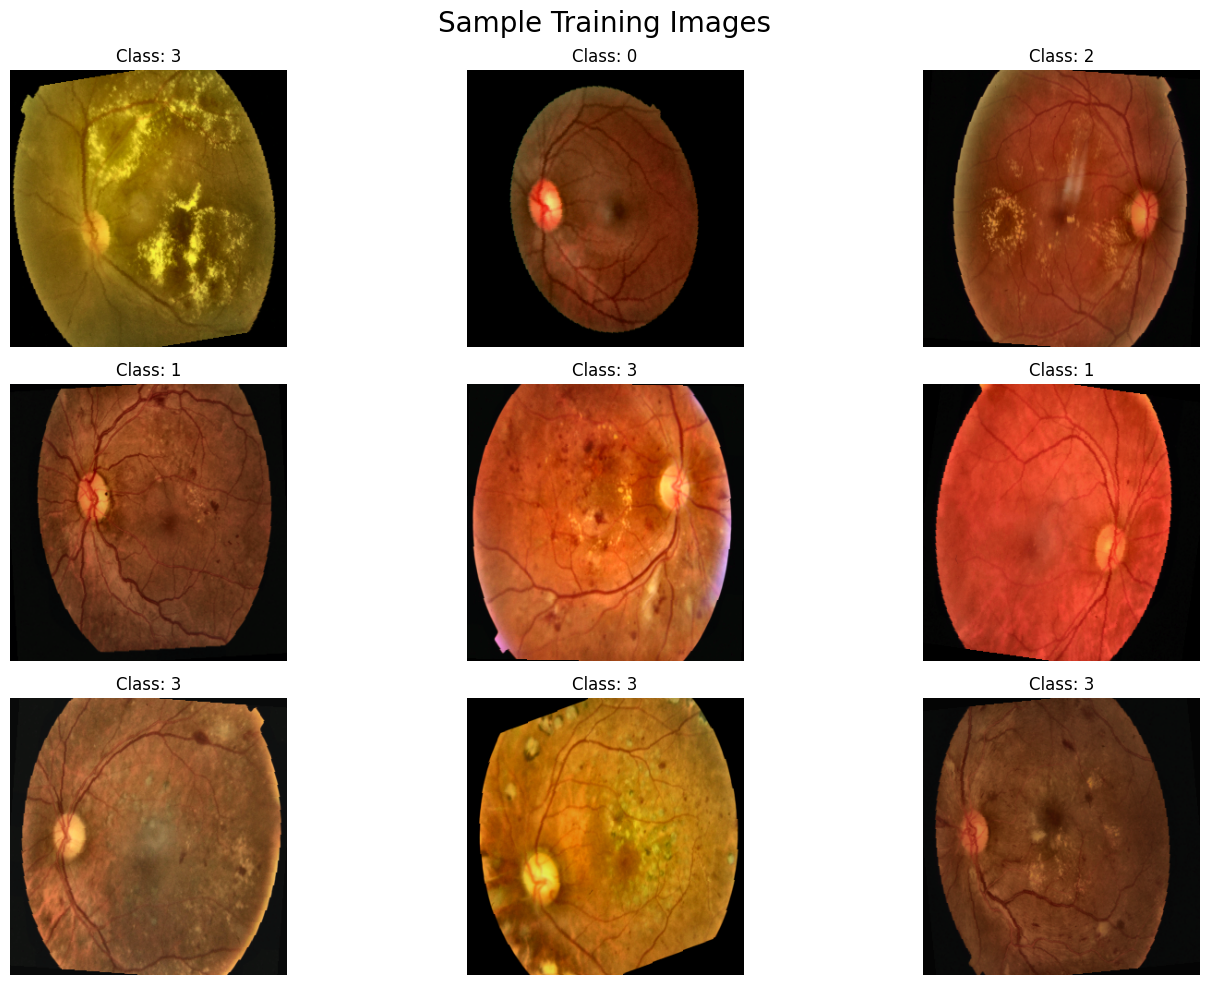

In [18]:
# ============================================================
# VISUALIZE SAMPLE TRAINING IMAGES
# ============================================================

# ============================================================
# GET ONE BATCH
# ============================================================

images, labels = next(

    iter(train_loader)
)

# ============================================================
# PLOT SETTINGS
# ============================================================

plt.figure(figsize=(15, 10))

# ============================================================
# SHOW FIRST 9 IMAGES
# ============================================================

for i in range(9):

    plt.subplot(3, 3, i + 1)

    # ========================================================
    # CONVERT TENSOR TO IMAGE
    # ========================================================

    image = images[i].permute(

        1,

        2,

        0
    ).numpy()

    # ========================================================
    # UNNORMALIZE IMAGE
    # ========================================================

    mean = np.array(

        [0.485, 0.456, 0.406]
    )

    std = np.array(

        [0.229, 0.224, 0.225]
    )

    image = std * image + mean

    image = np.clip(

        image,

        0,

        1
    )

    # ========================================================
    # DISPLAY IMAGE
    # ========================================================

    plt.imshow(image)

    plt.title(

        f"Class: {labels[i].item()}",
        
        fontsize=12
    )

    plt.axis("off")

plt.suptitle(

    "Sample Training Images",

    fontsize=20
)

plt.tight_layout()

plt.show()

In [19]:
# ============================================================
# LOAD PRETRAINED DENSENET121
# ============================================================

model = models.densenet121(

    pretrained=True
)

# ============================================================
# FREEZE BACKBONE
# PHASE 1 TRAINING
# ============================================================

for param in model.parameters():

    param.requires_grad = False

# ============================================================
# REPLACE FINAL CLASSIFIER
# ============================================================

in_features = model.classifier.in_features

model.classifier = nn.Sequential(

    nn.Linear(

        in_features,

        512
    ),

    nn.ReLU(),

    nn.Dropout(0.4),

    nn.Linear(

        512,

        256
    ),

    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(

        256,

        NUM_CLASSES
    )
)

# ============================================================
# UNFREEZE CLASSIFIER
# ============================================================

for param in model.classifier.parameters():

    param.requires_grad = True

# ============================================================
# MOVE MODEL TO GPU
# ============================================================

model = model.to(device)

print("="*50)

print("DenseNet121 Loaded Successfully!")

print("="*50)

print(model.classifier)

print("="*50)

DenseNet121 Loaded Successfully!
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=5, bias=True)
)


In [20]:
# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# PHASE 1
# ============================================================

optimizer = optim.Adam(

    model.classifier.parameters(),

    lr=PHASE1_LR
)

# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler = ReduceLROnPlateau(

    optimizer,

    mode='min',

    factor=0.5,

    patience=3
)

print("="*50)

print("Loss Function, Optimizer & Scheduler Ready!")

print("="*50)

print(f"Loss Function : CrossEntropyLoss")

print(f"Optimizer     : Adam")

print(f"Learning Rate : {PHASE1_LR}")

print("="*50)

Loss Function, Optimizer & Scheduler Ready!
Loss Function : CrossEntropyLoss
Optimizer     : Adam
Learning Rate : 0.001


In [21]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(

    model,

    loader,

    criterion,

    optimizer
):

    # ========================================================
    # TRAIN MODE
    # ========================================================

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    # ========================================================
    # PROGRESS BAR
    # ========================================================

    progress_bar = tqdm(

        loader,

        desc="Training",

        leave=True
    )

    # ========================================================
    # TRAIN LOOP
    # ========================================================

    for images, labels in progress_bar:

        # ====================================================
        # MOVE TO GPU
        # ====================================================

        images = images.to(device)

        labels = labels.to(device)

        # ====================================================
        # CLEAR GRADIENTS
        # ====================================================

        optimizer.zero_grad()

        # ====================================================
        # FORWARD PASS
        # ====================================================

        outputs = model(images)

        loss = criterion(

            outputs,

            labels
        )

        # ====================================================
        # BACKPROPAGATION
        # ====================================================

        loss.backward()

        optimizer.step()

        # ====================================================
        # CALCULATE ACCURACY
        # ====================================================

        _, predicted = torch.max(

            outputs,

            1
        )

        total += labels.size(0)

        correct += (

            predicted == labels
        ).sum().item()

        # ====================================================
        # UPDATE LOSS
        # ====================================================

        running_loss += loss.item()

        # ====================================================
        # CURRENT METRICS
        # ====================================================

        current_loss = (

            running_loss
            / len(loader)
        )

        current_accuracy = (

            100 * correct / total
        )

        # ====================================================
        # UPDATE PROGRESS BAR
        # ====================================================

        progress_bar.set_postfix({

            "Loss": f"{current_loss:.4f}",

            "Accuracy": f"{current_accuracy:.2f}%"
        })

    # ========================================================
    # FINAL METRICS
    # ========================================================

    epoch_loss = (

        running_loss
        / len(loader)
    )

    epoch_accuracy = (

        100 * correct / total
    )

    return epoch_loss, epoch_accuracy

In [22]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(

    model,

    loader,

    criterion
):

    # ========================================================
    # EVALUATION MODE
    # ========================================================

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    # ========================================================
    # DISABLE GRADIENTS
    # ========================================================

    with torch.no_grad():

        # ====================================================
        # PROGRESS BAR
        # ====================================================

        progress_bar = tqdm(

            loader,

            desc="Validation",

            leave=True
        )

        # ====================================================
        # VALIDATION LOOP
        # ====================================================

        for images, labels in progress_bar:

            # ================================================
            # MOVE TO GPU
            # ================================================

            images = images.to(device)

            labels = labels.to(device)

            # ================================================
            # FORWARD PASS
            # ================================================

            outputs = model(images)

            loss = criterion(

                outputs,

                labels
            )

            # ================================================
            # PREDICTIONS
            # ================================================

            _, predicted = torch.max(

                outputs,

                1
            )

            total += labels.size(0)

            correct += (

                predicted == labels
            ).sum().item()

            # ================================================
            # UPDATE LOSS
            # ================================================

            running_loss += loss.item()

            # ================================================
            # CURRENT METRICS
            # ================================================

            current_loss = (

                running_loss
                / len(loader)
            )

            current_accuracy = (

                100 * correct / total
            )

            # ================================================
            # UPDATE PROGRESS BAR
            # ================================================

            progress_bar.set_postfix({

                "Loss": f"{current_loss:.4f}",

                "Accuracy": f"{current_accuracy:.2f}%"
            })

    # ========================================================
    # FINAL METRICS
    # ========================================================

    epoch_loss = (

        running_loss
        / len(loader)
    )

    epoch_accuracy = (

        100 * correct / total
    )

    return epoch_loss, epoch_accuracy

In [23]:
# ============================================================
# TRAINING VARIABLES
# ============================================================

train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []

# ============================================================
# BEST VALIDATION ACCURACY
# ============================================================

best_val_accuracy = 0.0

# ============================================================
# EARLY STOPPING
# ============================================================

early_stop_counter = 0

print("="*50)

print("Training Variables Initialized!")

print("="*50)

Training Variables Initialized!


In [ ]:
# ============================================================
# PHASE 1 TRAINING
# TRAIN ONLY CLASSIFIER
# ============================================================

print("="*60)

print("PHASE 1 TRAINING STARTED")

print("="*60)

# ============================================================
# TRAINING START TIME
# ============================================================

phase1_start_time = time.time()

# ============================================================
# PHASE 1 EPOCHS
# ============================================================

PHASE1_EPOCHS = 15

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(PHASE1_EPOCHS):

    print("\n" + "="*60)

    print(f"Epoch [{epoch+1}/{PHASE1_EPOCHS}]")

    print("="*60)

    # ========================================================
    # EPOCH START TIME
    # ========================================================

    epoch_start_time = time.time()

    # ========================================================
    # TRAINING
    # ========================================================

    train_loss, train_accuracy = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_loss, val_accuracy = validate_one_epoch(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # STORE METRICS
    # ========================================================

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)

    val_accuracies.append(val_accuracy)

    # ========================================================
    # LR SCHEDULER
    # ========================================================

    scheduler.step(val_loss)

    # ========================================================
    # CURRENT LEARNING RATE
    # ========================================================

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # EPOCH TIME
    # ========================================================

    epoch_time = (

        time.time()
        - epoch_start_time
    )

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\n" + "-"*50)

    print(f"Train Loss         : {train_loss:.4f}")

    print(f"Train Accuracy     : {train_accuracy:.2f}%")

    print(f"Validation Loss    : {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    print(f"Learning Rate      : {current_lr:.7f}")

    print(f"Epoch Time         : {epoch_time:.2f} seconds")

    print("-"*50)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(

            model.state_dict(),

            PHASE1_MODEL_PATH
        )

        print("\nBest Phase 1 Model Saved!")

        early_stop_counter = 0

    else:

        early_stop_counter += 1

        print(

            f"\nEarly Stop Counter: "
            f"{early_stop_counter}/{PATIENCE}"
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if early_stop_counter >= PATIENCE:

        print("\nEarly Stopping Triggered!")

        break

# ============================================================
# SAVE PHASE 1 HISTORY
# ============================================================

history_phase1 = {

    "train_accuracies": train_accuracies,

    "val_accuracies": val_accuracies,

    "train_losses": train_losses,

    "val_losses": val_losses,

    "best_val_accuracy": best_val_accuracy,

    "final_learning_rate": current_lr,

    "total_epochs_completed": epoch + 1
}

torch.save(

    history_phase1,

    "../models/densenet121/history_phase1.pth"
)

print("="*60)

print("Phase 1 History Saved Successfully!")

print("="*60)

# ============================================================
# TOTAL TRAINING TIME
# ============================================================

phase1_total_time = (

    time.time()
    - phase1_start_time
)

print("\n" + "="*60)

print("PHASE 1 TRAINING COMPLETED!")

print("="*60)

print(

    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(

    f"Total Training Time: "
    f"{phase1_total_time/60:.2f} Minutes"
)

print("="*60)

PHASE 1 TRAINING STARTED

Epoch [1/15]


Validation: 100%|██████████| 8/8 [00:19<00:00,  2.43s/it, Loss=1.1975, Accuracy=49.78%]



--------------------------------------------------
Train Loss         : 1.4866
Train Accuracy     : 29.81%
Validation Loss    : 1.1975
Validation Accuracy: 49.78%
Learning Rate      : 0.0010000
Epoch Time         : 88.77 seconds
--------------------------------------------------

Best Phase 1 Model Saved!

Epoch [2/15]


Validation: 100%|██████████| 8/8 [00:15<00:00,  2.00s/it, Loss=1.0991, Accuracy=53.33%]



--------------------------------------------------
Train Loss         : 1.2220
Train Accuracy     : 46.86%
Validation Loss    : 1.0991
Validation Accuracy: 53.33%
Learning Rate      : 0.0010000
Epoch Time         : 86.79 seconds
--------------------------------------------------

Best Phase 1 Model Saved!

Epoch [3/15]


...


--------------------------------------------------
Train Loss         : 0.9129
Train Accuracy     : 61.05%
Validation Loss    : 0.9037
Validation Accuracy: 60.44%
Learning Rate      : 0.0005000
Epoch Time         : 164.68 seconds
--------------------------------------------------

Best Phase 1 Model Saved!

Epoch [14/15]


Validation: 100%|██████████| 8/8 [00:33<00:00,  4.22s/it, Loss=0.8849, Accuracy=63.56%]



--------------------------------------------------
Train Loss         : 0.9083
Train Accuracy     : 60.67%
Validation Loss    : 0.8849
Validation Accuracy: 63.56%
Learning Rate      : 0.0005000
Epoch Time         : 177.45 seconds
--------------------------------------------------

Best Phase 1 Model Saved!

Epoch [15/15]


Validation: 100%|██████████| 8/8 [00:17<00:00,  2.24s/it, Loss=0.9200, Accuracy=56.89%]


--------------------------------------------------
Train Loss         : 0.9072
Train Accuracy     : 59.24%
Validation Loss    : 0.9200
Validation Accuracy: 56.89%
Learning Rate      : 0.0005000
Epoch Time         : 175.84 seconds
--------------------------------------------------

Early Stop Counter: 1/15

PHASE 1 TRAINING COMPLETED!
Best Validation Accuracy: 63.56%
Total Training Time: 38.00 Minutes


In [24]:
# ============================================================
# LOAD BEST PHASE 1 MODEL
# ============================================================

model.load_state_dict(

    torch.load(PHASE1_MODEL_PATH)
)

print("="*50)

print("Best Phase 1 Model Loaded Successfully!")

print("="*50)

Best Phase 1 Model Loaded Successfully!


In [25]:
# ============================================================
# PHASE 2
# PARTIAL BACKBONE FINE TUNING
# ============================================================

print("="*60)

print("PHASE 2 INITIALIZATION")

print("="*60)

# ============================================================
# UNFREEZE DENSEBLOCK4
# ============================================================

for param in model.features.denseblock4.parameters():

    param.requires_grad = True

# ============================================================
# UNFREEZE TRANSITION3
# ============================================================

for param in model.features.transition3.parameters():

    param.requires_grad = True

print("DenseBlock4 Unfrozen!")

print("Transition3 Unfrozen!")

print("="*60)

# ============================================================
# COUNT TRAINABLE PARAMETERS
# ============================================================

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

total_params = sum(

    p.numel()

    for p in model.parameters()
)

print(

    f"Trainable Parameters: "
    f"{trainable_params:,}"
)

print(

    f"Total Parameters: "
    f"{total_params:,}"
)

print("="*60)

PHASE 2 INITIALIZATION
DenseBlock4 Unfrozen!
Transition3 Unfrozen!
Trainable Parameters: 3,341,829
Total Parameters: 7,611,269


In [26]:
# ============================================================
# PHASE 2 OPTIMIZER
# ============================================================

optimizer = optim.Adam(

    filter(

        lambda p: p.requires_grad,

        model.parameters()
    ),

    lr=PHASE2_LR
)

# ============================================================
# PHASE 2 LR SCHEDULER
# ============================================================

scheduler = ReduceLROnPlateau(

    optimizer,

    mode='min',

    factor=0.5,

    patience=3
)

print("="*60)

print("PHASE 2 OPTIMIZER READY")

print("="*60)

print(f"Learning Rate: {PHASE2_LR}")

print("="*60)

PHASE 2 OPTIMIZER READY
Learning Rate: 0.0001


In [27]:
# ============================================================
# RESET PHASE 2 VARIABLES
# ============================================================

best_val_accuracy = 0.0

early_stop_counter = 0

# ============================================================
# PHASE 2 EPOCHS
# ============================================================

PHASE2_EPOCHS = 30

print("="*60)

print("PHASE 2 VARIABLES RESET")

print("="*60)

print(f"Phase 2 Epochs : {PHASE2_EPOCHS}")

print(f"Patience       : {PATIENCE}")

print("="*60)

PHASE 2 VARIABLES RESET
Phase 2 Epochs : 30
Patience       : 15


In [ ]:
# ============================================================
# PHASE 2 TRAINING LOOP
# PARTIAL BACKBONE FINE TUNING
# ============================================================

print("="*60)

print("PHASE 2 TRAINING STARTED")

print("="*60)

# ============================================================
# PHASE 2 START TIME
# ============================================================

phase2_start_time = time.time()

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(PHASE2_EPOCHS):

    print("\n" + "="*60)

    print(f"Phase 2 Epoch [{epoch+1}/{PHASE2_EPOCHS}]")

    print("="*60)

    # ========================================================
    # EPOCH START TIME
    # ========================================================

    epoch_start_time = time.time()

    # ========================================================
    # TRAINING
    # ========================================================

    train_loss, train_accuracy = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_loss, val_accuracy = validate_one_epoch(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # STORE METRICS
    # ========================================================

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)

    val_accuracies.append(val_accuracy)

    # ========================================================
    # LR SCHEDULER
    # ========================================================

    scheduler.step(val_loss)

    # ========================================================
    # CURRENT LEARNING RATE
    # ========================================================

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # EPOCH TIME
    # ========================================================

    epoch_time = (

        time.time()
        - epoch_start_time
    )

    # ========================================================
    # PRINT METRICS
    # ========================================================

    print("\n" + "-"*50)

    print(f"Train Loss         : {train_loss:.4f}")

    print(f"Train Accuracy     : {train_accuracy:.2f}%")

    print(f"Validation Loss    : {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    print(f"Learning Rate      : {current_lr:.7f}")

    print(f"Epoch Time         : {epoch_time:.2f} seconds")

    print("-"*50)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(

            model.state_dict(),

            PHASE2_MODEL_PATH
        )

        print("\nBest Phase 2 Model Saved!")

        print(

            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        print(

            f"Validation Loss: "
            f"{val_loss:.4f}"
        )

        early_stop_counter = 0

    else:

        early_stop_counter += 1

        print(

            f"\nEarly Stop Counter: "
            f"{early_stop_counter}/{PATIENCE}"
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if early_stop_counter >= PATIENCE:

        print("\nEarly Stopping Triggered!")

        break

# ============================================================
# SAVE PHASE 2 HISTORY
# ============================================================

history_phase2 = {

    "train_accuracies": train_accuracies,

    "val_accuracies": val_accuracies,

    "train_losses": train_losses,

    "val_losses": val_losses,

    "best_val_accuracy": best_val_accuracy,

    "final_learning_rate": current_lr,

    "total_epochs_completed": epoch + 1
}

torch.save(

    history_phase2,

    "../models/densenet121/history_phase2.pth"
)

print("="*60)

print("Phase 2 History Saved Successfully!")

print("="*60)

# ============================================================
# TOTAL TRAINING TIME
# ============================================================

phase2_total_time = (

    time.time()
    - phase2_start_time
)

print("\n" + "="*60)

print("PHASE 2 TRAINING COMPLETED!")

print("="*60)

print(

    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(

    f"Total Training Time: "
    f"{phase2_total_time/60:.2f} Minutes"
)

print("="*60)

PHASE 2 TRAINING STARTED

Phase 2 Epoch [1/30]


Validation: 100%|██████████| 8/8 [00:38<00:00,  4.81s/it, Loss=0.8776, Accuracy=65.33%]



--------------------------------------------------
Train Loss         : 0.8798
Train Accuracy     : 60.38%
Validation Loss    : 0.8776
Validation Accuracy: 65.33%
Learning Rate      : 0.0001000
Epoch Time         : 180.14 seconds
--------------------------------------------------

Best Phase 2 Model Saved!
Best Validation Accuracy: 65.33%
Validation Loss: 0.8776

Phase 2 Epoch [2/30]


Validation: 100%|██████████| 8/8 [00:36<00:00,  4.59s/it, Loss=0.8314, Accuracy=62.22%]



--------------------------------------------------
Train Loss         : 0.8189
Train Accuracy     : 66.48%
Validation Loss    : 0.8314
Validation Accuracy: 62.22%
Learning Rate      : 0.0001000
Epoch Time         : 206.40 seconds
--------------------------------------------------

Early Stop Counter: 1/15

Phase 2 Epoch [3/30]


...


--------------------------------------------------
Train Loss         : 0.2581
Train Accuracy     : 91.43%
Validation Loss    : 0.7499
Validation Accuracy: 68.00%
Learning Rate      : 0.0000125
Epoch Time         : 209.21 seconds
--------------------------------------------------

Early Stop Counter: 13/15

Phase 2 Epoch [26/30]


Validation: 100%|██████████| 8/8 [00:37<00:00,  4.67s/it, Loss=0.7609, Accuracy=67.56%]



--------------------------------------------------
Train Loss         : 0.2765
Train Accuracy     : 89.62%
Validation Loss    : 0.7609
Validation Accuracy: 67.56%
Learning Rate      : 0.0000063
Epoch Time         : 218.20 seconds
--------------------------------------------------

Early Stop Counter: 14/15

Phase 2 Epoch [27/30]


Validation: 100%|██████████| 8/8 [00:37<00:00,  4.66s/it, Loss=0.7526, Accuracy=68.00%]


--------------------------------------------------
Train Loss         : 0.2492
Train Accuracy     : 91.62%
Validation Loss    : 0.7526
Validation Accuracy: 68.00%
Learning Rate      : 0.0000063
Epoch Time         : 210.77 seconds
--------------------------------------------------

Early Stop Counter: 15/15

Early Stopping Triggered!

PHASE 2 TRAINING COMPLETED!
Best Validation Accuracy: 71.11%
Total Training Time: 94.17 Minutes


In [28]:
# ============================================================
# LOAD BEST PHASE 2 MODEL
# ============================================================

model.load_state_dict(

    torch.load(PHASE2_MODEL_PATH)
)

print("="*60)

print("Best Phase 2 Model Loaded Successfully!")

print("="*60)

Best Phase 2 Model Loaded Successfully!


In [29]:
# ============================================================
# PHASE 3
# FULL NETWORK FINE TUNING
# ============================================================

print("="*60)

print("PHASE 3 INITIALIZATION")

print("="*60)

# ============================================================
# UNFREEZE ENTIRE NETWORK
# ============================================================

for param in model.parameters():

    param.requires_grad = True

print("Entire DenseNet121 Unfrozen!")

print("="*60)

# ============================================================
# COUNT TRAINABLE PARAMETERS
# ============================================================

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

total_params = sum(

    p.numel()

    for p in model.parameters()
)

print(

    f"Trainable Parameters: "
    f"{trainable_params:,}"
)

print(

    f"Total Parameters: "
    f"{total_params:,}"
)

print("="*60)

PHASE 3 INITIALIZATION
Entire DenseNet121 Unfrozen!
Trainable Parameters: 7,611,269
Total Parameters: 7,611,269


In [30]:
# ============================================================
# PHASE 3 LOSS FUNCTION
# LABEL SMOOTHING
# ============================================================

criterion = nn.CrossEntropyLoss(

    label_smoothing=0.1
)

# ============================================================
# PHASE 3 OPTIMIZER
# VERY LOW LR TO AVOID OVERFITTING
# ============================================================

optimizer = optim.Adam(

    model.parameters(),

    lr=5e-6,

    weight_decay=1e-4
)

# ============================================================
# LR SCHEDULER
# ============================================================

scheduler = ReduceLROnPlateau(

    optimizer,

    mode='min',

    factor=0.5,

    patience=3
)

print("="*60)

print("PHASE 3 OPTIMIZER READY")

print("="*60)

print("Label Smoothing : 0.1")

print("Weight Decay    : 1e-4")

print("Learning Rate   : 0.000005")

print("="*60)

PHASE 3 OPTIMIZER READY
Label Smoothing : 0.1
Weight Decay    : 1e-4
Learning Rate   : 0.000005


In [31]:
# ============================================================
# RESET VARIABLES
# ============================================================

best_val_accuracy = 0.0

early_stop_counter = 0

# ============================================================
# PHASE 3 EPOCHS
# ============================================================

PHASE3_EPOCHS = 55

print("="*60)

print("PHASE 3 VARIABLES RESET")

print("="*60)

print(f"Phase 3 Epochs : {PHASE3_EPOCHS}")

print(f"Patience       : {PATIENCE}")

print("="*60)

PHASE 3 VARIABLES RESET
Phase 3 Epochs : 55
Patience       : 15


In [ ]:
# ============================================================
# PHASE 3 TRAINING LOOP
# FULL NETWORK FINE TUNING
# ============================================================

print("="*60)

print("PHASE 3 TRAINING STARTED")

print("="*60)

# ============================================================
# PHASE 3 START TIME
# ============================================================

phase3_start_time = time.time()

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(PHASE3_EPOCHS):

    print("\n" + "="*60)

    print(f"Phase 3 Epoch [{epoch+1}/{PHASE3_EPOCHS}]")

    print("="*60)

    # ========================================================
    # EPOCH START TIME
    # ========================================================

    epoch_start_time = time.time()

    # ========================================================
    # TRAINING
    # ========================================================

    train_loss, train_accuracy = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_loss, val_accuracy = validate_one_epoch(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # STORE METRICS
    # ========================================================

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)

    val_accuracies.append(val_accuracy)

    # ========================================================
    # LR SCHEDULER
    # ========================================================

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # EPOCH TIME
    # ========================================================

    epoch_time = (

        time.time()
        - epoch_start_time
    )

    # ========================================================
    # PRINT METRICS
    # ========================================================

    print("\n" + "-"*50)

    print(f"Train Loss         : {train_loss:.4f}")

    print(f"Train Accuracy     : {train_accuracy:.2f}%")

    print(f"Validation Loss    : {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    print(f"Learning Rate      : {current_lr:.8f}")

    print(f"Epoch Time         : {epoch_time:.2f} seconds")

    print("-"*50)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(

            model.state_dict(),

            FINAL_MODEL_PATH
        )

        print("\nBest Final Model Saved!")

        print(

            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        print(

            f"Validation Loss: "
            f"{val_loss:.4f}"
        )

        early_stop_counter = 0

    else:

        early_stop_counter += 1

        print(

            f"\nEarly Stop Counter: "
            f"{early_stop_counter}/{PATIENCE}"
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if early_stop_counter >= PATIENCE:

        print("\nEarly Stopping Triggered!")

        break

# ============================================================
# SAVE FINAL TRAINING HISTORY
# ============================================================

final_history = {

    "train_accuracies": train_accuracies,

    "val_accuracies": val_accuracies,

    "train_losses": train_losses,

    "val_losses": val_losses,

    "best_val_accuracy": best_val_accuracy,

    "final_learning_rate": current_lr,

    "total_epochs_completed": epoch + 1
}

torch.save(

    final_history,

    "../models/densenet121/final_history.pth"
)

print("="*60)

print("Final Training History Saved Successfully!")

print("="*60)

# ============================================================
# TOTAL TRAINING TIME
# ============================================================

phase3_total_time = (

    time.time()
    - phase3_start_time
)

print("\n" + "="*60)

print("PHASE 3 TRAINING COMPLETED!")

print("="*60)

print(

    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(

    f"Total Training Time: "
    f"{phase3_total_time/60:.2f} Minutes"
)

print("="*60)

PHASE 3 TRAINING STARTED

Phase 3 Epoch [1/55]


Validation: 100%|██████████| 8/8 [00:34<00:00,  4.27s/it, Loss=1.1659, Accuracy=68.89%]



--------------------------------------------------
Train Loss         : 0.9159
Train Accuracy     : 81.90%
Validation Loss    : 1.1659
Validation Accuracy: 68.89%
Learning Rate      : 0.00000500
Epoch Time         : 145.49 seconds
--------------------------------------------------

Best Final Model Saved!
Best Validation Accuracy: 68.89%
Validation Loss: 1.1659

Phase 3 Epoch [2/55]


Validation: 100%|██████████| 8/8 [00:34<00:00,  4.28s/it, Loss=1.1201, Accuracy=69.33%]



--------------------------------------------------
Train Loss         : 0.8773
Train Accuracy     : 85.33%
Validation Loss    : 1.1201
Validation Accuracy: 69.33%
Learning Rate      : 0.00000500
Epoch Time         : 193.65 seconds
--------------------------------------------------

Best Final Model Saved!
Best Validation Accuracy: 69.33%
Validation Loss: 1.1201

Phase 3 Epoch [3/55]


...


--------------------------------------------------
Train Loss         : 0.7470
Train Accuracy     : 87.71%
Validation Loss    : 1.0088
Validation Accuracy: 66.67%
Learning Rate      : 0.00000500
Epoch Time         : 72.69 seconds
--------------------------------------------------

Early Stop Counter: 13/15

Phase 3 Epoch [16/55]


Validation: 100%|██████████| 8/8 [00:11<00:00,  1.49s/it, Loss=1.0011, Accuracy=68.00%]



--------------------------------------------------
Train Loss         : 0.7508
Train Accuracy     : 86.95%
Validation Loss    : 1.0011
Validation Accuracy: 68.00%
Learning Rate      : 0.00000500
Epoch Time         : 67.37 seconds
--------------------------------------------------

Early Stop Counter: 14/15

Phase 3 Epoch [17/55]


Validation: 100%|██████████| 8/8 [00:11<00:00,  1.41s/it, Loss=0.9952, Accuracy=68.00%]


--------------------------------------------------
Train Loss         : 0.7259
Train Accuracy     : 88.57%
Validation Loss    : 0.9952
Validation Accuracy: 68.00%
Learning Rate      : 0.00000500
Epoch Time         : 65.76 seconds
--------------------------------------------------

Early Stop Counter: 15/15

Early Stopping Triggered!

PHASE 3 TRAINING COMPLETED!
Best Validation Accuracy: 69.33%
Total Training Time: 26.80 Minutes


In [32]:
# ============================================================
# MODEL PATHS
# ============================================================

PHASE2_MODEL_PATH = (

    "../models/densenet121/"
    "best_densenet121_phase2.pth"
)

FINAL_MODEL_PATH = (

    "../models/densenet121/"
    "best_densenet121_final.pth"
)

print("="*60)

print("Model Paths Loaded Successfully!")

print("="*60)

print(f"Phase 2 Model : {PHASE2_MODEL_PATH}")

print(f"Final Model   : {FINAL_MODEL_PATH}")

print("="*60)

Model Paths Loaded Successfully!
Phase 2 Model : ../models/densenet121/best_densenet121_phase2.pth
Final Model   : ../models/densenet121/best_densenet121_final.pth


In [33]:
from torchvision import models

print("Torchvision models imported successfully!")

import torch.nn as nn

print("torch.nn imported successfully!")

Torchvision models imported successfully!
torch.nn imported successfully!


In [35]:
# ============================================================
# RECREATE DENSENET121 MODEL
# ============================================================
print(type(model))
model = models.densenet121(

    weights=None
)

# ============================================================
# GET INPUT FEATURES
# ============================================================

in_features = model.classifier.in_features

# ============================================================
# REPLACE CLASSIFIER
# ============================================================

model.classifier = nn.Sequential(

    nn.Linear(

        in_features,

        512
    ),

    nn.ReLU(),

    nn.Dropout(0.4),

    nn.Linear(

        512,

        256
    ),

    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(

        256,

        NUM_CLASSES
    )
)

# ============================================================
# MOVE MODEL TO GPU / CPU
# ============================================================

model = model.to(device)

print("="*60)

print("DenseNet121 Recreated Successfully!")

print("="*60)

print(model.classifier)

print("="*60)

<class 'torchvision.models.densenet.DenseNet'>
DenseNet121 Recreated Successfully!
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=5, bias=True)
)


In [36]:
# ============================================================
# LOAD BEST PHASE 2 MODEL
# ============================================================

model.load_state_dict(

    torch.load(PHASE2_MODEL_PATH)
)

model.eval()

print("="*60)

print("Best Phase 2 Model Loaded Successfully!")

print("="*60)

Best Phase 2 Model Loaded Successfully!


In [37]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

all_labels = []

all_predictions = []

correct = 0

total = 0

# ============================================================
# DISABLE GRADIENTS
# ============================================================

with torch.no_grad():

    progress_bar = tqdm(

        test_loader,

        desc="Testing"
    )

    for images, labels in progress_bar:

        # ====================================================
        # MOVE TO DEVICE
        # ====================================================

        images = images.to(device)

        labels = labels.to(device)

        # ====================================================
        # MODEL PREDICTION
        # ====================================================

        outputs = model(images)

        _, predicted = torch.max(

            outputs,

            1
        )

        # ====================================================
        # STORE RESULTS
        # ====================================================

        all_labels.extend(

            labels.cpu().numpy()
        )

        all_predictions.extend(

            predicted.cpu().numpy()
        )

        # ====================================================
        # ACCURACY
        # ====================================================

        total += labels.size(0)

        correct += (

            predicted == labels
        ).sum().item()

# ============================================================
# FINAL TEST ACCURACY
# ============================================================

test_accuracy = (

    100 * correct / total
)

print("\n" + "="*60)

print(f"Final Test Accuracy: {test_accuracy:.2f}%")

print("="*60)

Testing: 100%|██████████| 8/8 [00:15<00:00,  1.92s/it]


Final Test Accuracy: 68.00%


In [38]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("="*60)

print("CLASSIFICATION REPORT")

print("="*60)

report = classification_report(

    all_labels,

    all_predictions,

    target_names=class_names
)

print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        45
           1       0.69      0.60      0.64        45
           2       0.49      0.49      0.49        45
           3       0.64      0.78      0.70        45
           4       0.70      0.58      0.63        45

    accuracy                           0.68       225
   macro avg       0.68      0.68      0.68       225
weighted avg       0.68      0.68      0.68       225



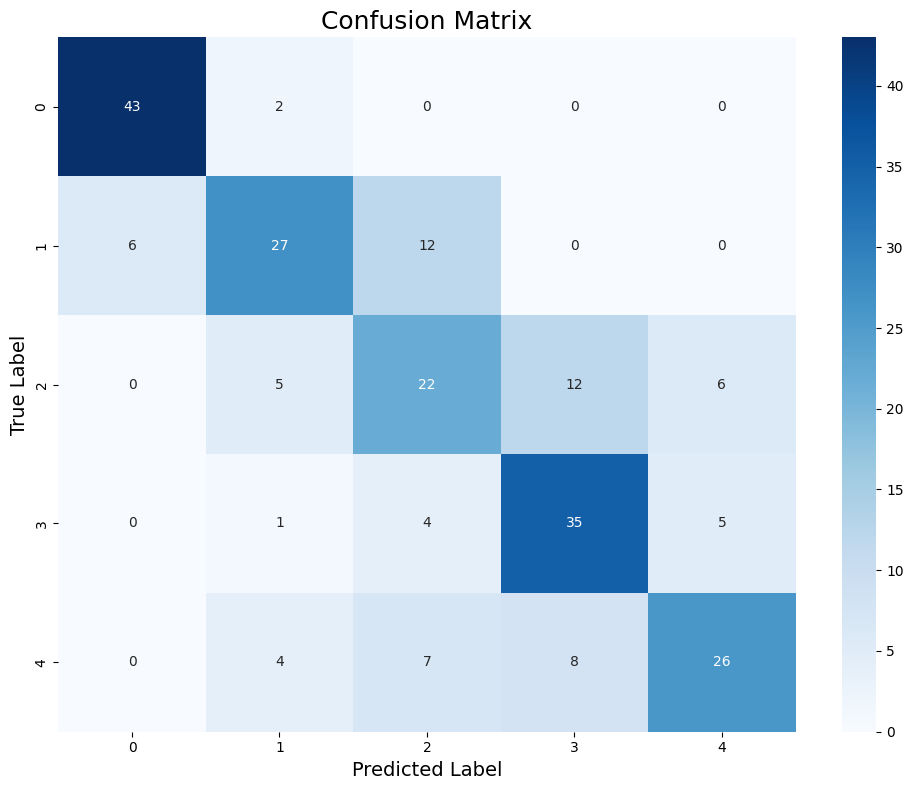

In [39]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    all_labels,

    all_predictions
)

# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title(

    "Confusion Matrix",

    fontsize=18
)

plt.xlabel(

    "Predicted Label",

    fontsize=14
)

plt.ylabel(

    "True Label",

    fontsize=14
)

plt.tight_layout()

plt.show()

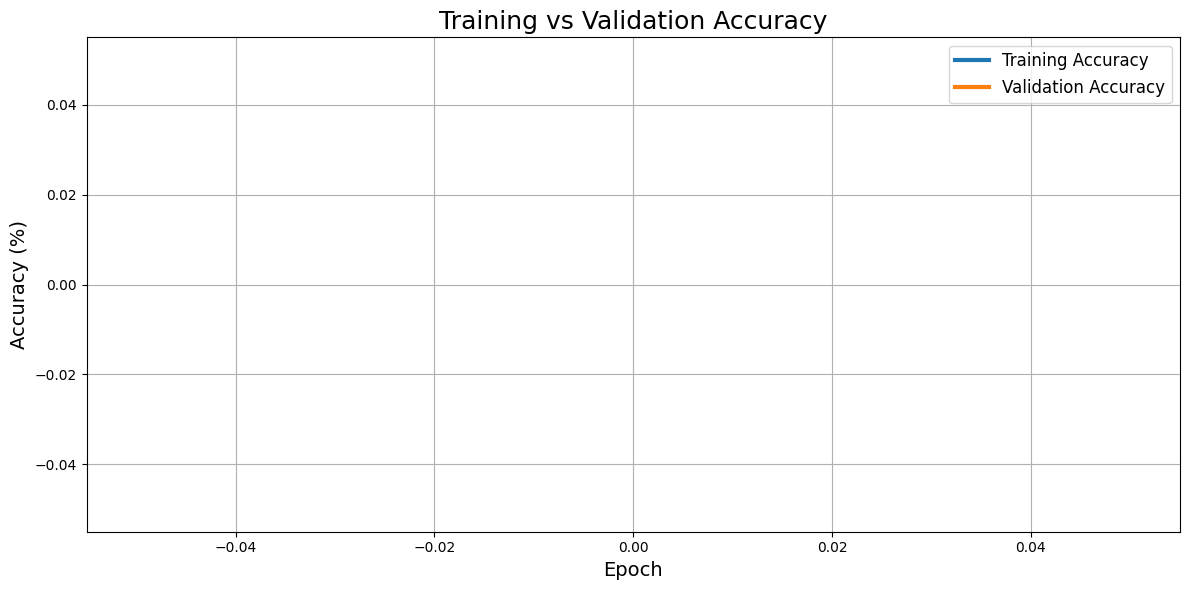

[]
[]


In [41]:
# ============================================================
# ACCURACY CURVES
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(

    train_accuracies,

    label="Training Accuracy",

    linewidth=3
)

plt.plot(

    val_accuracies,

    label="Validation Accuracy",

    linewidth=3
)

plt.title(

    "Training vs Validation Accuracy",

    fontsize=18
)

plt.xlabel(

    "Epoch",

    fontsize=14
)

plt.ylabel(

    "Accuracy (%)",

    fontsize=14
)

plt.legend(

    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

print(train_accuracies)
print(val_accuracies)

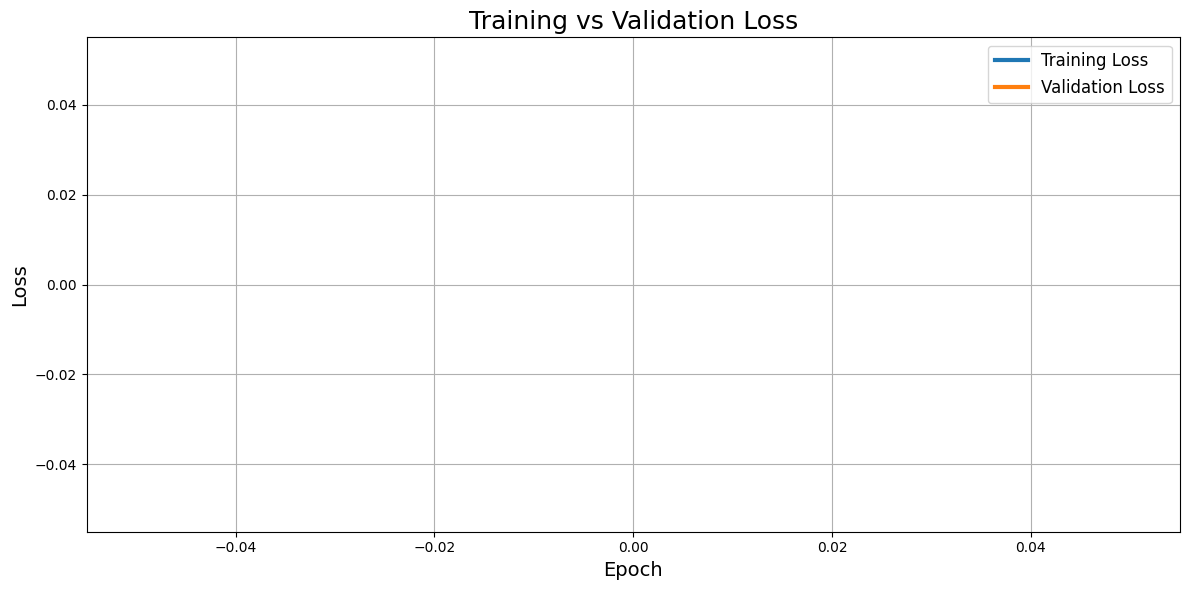

In [42]:
# ============================================================
# LOSS CURVES
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(

    train_losses,

    label="Training Loss",

    linewidth=3
)

plt.plot(

    val_losses,

    label="Validation Loss",

    linewidth=3
)

plt.title(

    "Training vs Validation Loss",

    fontsize=18
)

plt.xlabel(

    "Epoch",

    fontsize=14
)

plt.ylabel(

    "Loss",

    fontsize=14
)

plt.legend(

    fontsize=12
)

plt.grid(True)

plt.tight_layout()

plt.show()

Generating ROC Probabilities: 100%|██████████| 8/8 [00:12<00:00,  1.53s/it]


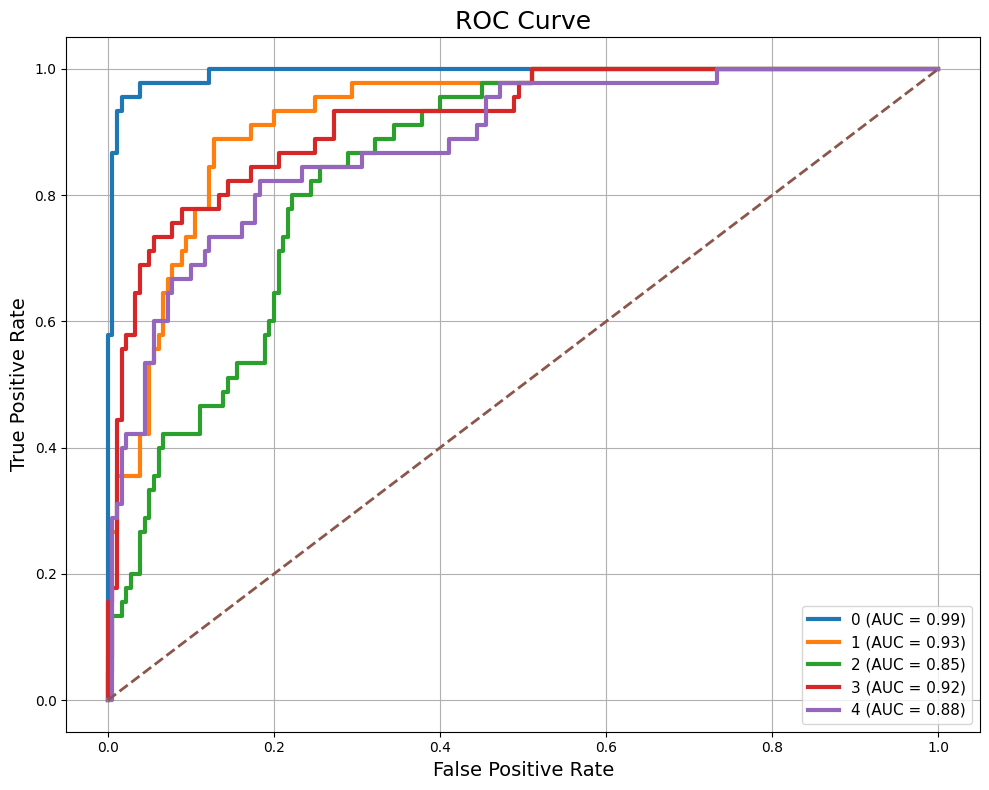

In [43]:
# ============================================================
# ROC CURVE
# ============================================================

from sklearn.preprocessing import label_binarize

# ============================================================
# BINARIZE LABELS
# ============================================================

y_true = label_binarize(

    all_labels,

    classes=[0, 1, 2, 3, 4]
)

# ============================================================
# GET PREDICTION PROBABILITIES
# ============================================================

all_probabilities = []

with torch.no_grad():

    progress_bar = tqdm(

        test_loader,

        desc="Generating ROC Probabilities"
    )

    for images, labels in progress_bar:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(

            outputs,

            dim=1
        )

        all_probabilities.extend(

            probabilities.cpu().numpy()
        )

all_probabilities = np.array(

    all_probabilities
)

# ============================================================
# PLOT ROC CURVES
# ============================================================

plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(

        y_true[:, i],

        all_probabilities[:, i]
    )

    roc_auc = auc(

        fpr,

        tpr
    )

    plt.plot(

        fpr,

        tpr,

        linewidth=3,

        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

# ============================================================
# RANDOM CLASSIFIER LINE
# ============================================================

plt.plot(

    [0, 1],

    [0, 1],

    linestyle='--',

    linewidth=2
)

# ============================================================
# LABELS & TITLE
# ============================================================

plt.title(

    "ROC Curve",

    fontsize=18
)

plt.xlabel(

    "False Positive Rate",

    fontsize=14
)

plt.ylabel(

    "True Positive Rate",

    fontsize=14
)

plt.legend(

    fontsize=11
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [44]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("\n" + "="*70)

print("FINAL DENSENET121 MODEL RESULTS")

print("="*70)

print(f"Best Validation Accuracy : {best_val_accuracy:.2f}%")

print(f"Final Test Accuracy      : {test_accuracy:.2f}%")

print("="*70)

print("CLASSIFICATION PERFORMANCE")

print("="*70)

report = classification_report(

    all_labels,

    all_predictions,

    target_names=class_names
)

print(report)

print("="*70)

print("MODEL USED")

print("="*70)

print("DenseNet121")

print("Phase 2 Best Checkpoint")

print(PHASE2_MODEL_PATH)

print("="*70)

print("EVALUATION COMPLETED SUCCESSFULLY!")

print("="*70)


FINAL DENSENET121 MODEL RESULTS
Best Validation Accuracy : 0.00%
Final Test Accuracy      : 68.00%
CLASSIFICATION PERFORMANCE
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        45
           1       0.69      0.60      0.64        45
           2       0.49      0.49      0.49        45
           3       0.64      0.78      0.70        45
           4       0.70      0.58      0.63        45

    accuracy                           0.68       225
   macro avg       0.68      0.68      0.68       225
weighted avg       0.68      0.68      0.68       225

MODEL USED
DenseNet121
Phase 2 Best Checkpoint
../models/densenet121/best_densenet121_phase2.pth
EVALUATION COMPLETED SUCCESSFULLY!
